# Fed-Balance-Sheet — a quantitative teardown 🔬
### Regime conditioning · HAC inference · block-bootstrap CI · excess-Sharpe race · synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Don't_fight_the_Fed%3F: Busted](https://img.shields.io/badge/Don't_fight_the_Fed%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We sort SPY daily returns by the Fed's announced balance-sheet direction and test the one contrast the slogan rests on (QE − QT) with an autocorrelation-robust *t* and a circular-block bootstrap, then race the literal timing rule on an excess-of-cash Sharpe.

> ⚠️ **Not investment advice.** Real tape: SPY daily, split-only / **price-only** (not total return), via the shared `quantlab` cache; regimes from a hand-built table standing in for the network-blocked FRED `WALCL`. Methods & sources in [`docs/references.md`](../docs/references.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
REG_COL = {"QE": GREEN, "QT": RED, "FLAT": GREY}

from fed_balance_sheet import data, strategy as st

# Cache-first real tape; fall back to the synthetic control if offline. The banner
# variable TAPE records which tape every cell below is actually showing.
def load_tape():
    try:
        bars = data.load_real("SPY", fetch=False)
        bars = bars.loc[bars.index < pd.Timestamp("2026-06-01")]  # drop partial month
        return bars, "REAL"
    except Exception as e:
        frame, _ = data.synthetic_daily(qe_edge=0.0, seed=317)   # NULL synthetic fallback
        return frame, "SYNTHETIC-NULL"

bars, TAPE = load_tape()
print("tape in use:", TAPE, "| rows:", len(bars), "| span:",
      bars.index.min().date(), "->", bars.index.max().date())
if TAPE == "REAL":
    print("fingerprint:", data.fingerprint(bars))


tape in use: REAL | rows: 8390 | span: 1993-01-29 -> 2026-05-29
fingerprint: d937d577b4c5


## Verdict, up front

| Axis | Stamp | The decisive number |
|---|---|---|
| **Signal** | **NONE** | QE − QT = +2.54 bps/day, 95% CI [-4.1, +9.15], *p* = 0.47; QT itself is *up* (*t* = +2.35). |
| **Tradability** | **MIRAGE** | Cash-in-QT -2.78%/yr vs buy-and-hold; short-in-QT -5.5%/yr (Sharpe 0.279 vs 0.552). |
| **"Don't fight the Fed"?** | **BUSTED** | Fighting the Fed in QT cost money over 33 years; the only live contrast is QE − FLAT (reverse causation: the Fed eases into crashes that rebound). |

> 💡 **In plain words.** The chart everyone shares is real — stocks *did* rise during QE. The trick is that they also rose during QT, so the *difference* (the only thing you could trade) is noise.

## 1 · The claim, steelmanned

- **H₁ (the slogan):** mean daily SPY return is higher in QE than in QT, by a margin large enough to clear an autocorrelation-robust *t* on the **difference**.
- **H₂ (tradable):** a rule that is long in QE/FLAT and cash-or-short in QT earns a *higher excess-of-cash Sharpe* than buy-and-hold, net of costs and one execution lag.
- **H₃ (causal direction):** any QE-vs-other gap reflects QE *driving* equities, not the Fed easing endogenously into drawdowns that mechanically rebound (the 'Fed put').

## 2 · So what? — what rides on each answer

If H₁ holds, the equity premium is partly a *policy* premium you can time off a public calendar — an enormous claim about market efficiency. If only H₃'s reverse-causation story holds, the overlay chart is a survivorship-of-attention artefact and the slogan is folklore. The desk has already found the *genuine* Fed calendar effects elsewhere (pre-FOMC drift, Study 67) — this study isolates the **balance-sheet-direction** claim specifically.

## 3 · How we'd know — the protocol

1. **Condition** daily returns on the announced regime (no fitting).
2. **Robust inference** — Newey–West HAC *t* on each regime mean and a circular-block bootstrap CI on the QE − QT contrast (block = 21 ≈ one trading month, preserving vol clustering).
3. **Critique** — check whether any gap is QE − QT (the slogan) or merely QE − FLAT (reverse causation).
4. **Trade it** — long-QE / cash-or-short-QT, **one** execution lag, one-way costs × NAV, raced on **excess-of-cash** Sharpe (the rule sits in cash part-time).
5. **Synthetic control** — confirm the harness banks a *planted* QE>QT edge and finds nothing on the null.

> 🔬 **Falsifier, declared up front:** if the QE − QT bootstrap CI straddles zero, we stamp **NONE** — no goalpost-moving afterward.

In [2]:
# Regime means with HAC t-stats.
rm = st.regime_means(bars)
print(f"[tape: {TAPE}]  H0 for each tstat: mean daily return = 0")
rm.round(3)


[tape: REAL]  H0 for each tstat: mean daily return = 0


,n,mean_bps,vol_bps,sharpe_ann,tstat
QE,1536.0,8.348,122.691,1.080,3.086
FLAT,5391.0,2.396,119.595,0.318,1.754
QT,1462.0,5.812,101.659,0.908,2.347


> 💡 **In plain words.** Every regime — including QT — has a positive, often *significant* up-drift. That alone sinks the slogan: 'fight the Fed in QT' would have you flat or short during a rising market.

## 4 · The teardown

### 4.1 The decisive contrast — QE − QT (block bootstrap)

In [3]:
ci_qt = st.diff_block_bootstrap_ci(bars, a='QE', b='QT', n_boot=3000, seed=317)
ci_fl = st.diff_block_bootstrap_ci(bars, a='QE', b='FLAT', n_boot=3000, seed=317)
print(f"[tape: {TAPE}]")
for name, ci in [('QE - QT  ', ci_qt), ('QE - FLAT', ci_fl)]:
    print(f"{name}: {ci['diff_bps']:+6.2f} bps  CI [{ci['ci_lo']:+.2f}, "
          f"{ci['ci_hi']:+.2f}]  p={ci['p_boot']:.3f}")


[tape: REAL]
QE - QT  :  +2.54 bps  CI [-4.05, +9.15]  p=0.467
QE - FLAT:  +5.95 bps  CI [+0.39, +11.35]  p=0.039


> 💡 **In plain words.** **QE − QT** = +2.54 bps, CI [-4.1, +9.15], *p* = 0.47 — the slogan's contrast is noise. The only flicker is **QE − FLAT** (+5.95 bps, *p* = 0.038): the Fed eases hardest into crashes, and stocks rebound off the bottom — H₃'s reverse causation, not a tradable QE/QT edge.

### 4.2 Could you trade it? — the excess-of-cash race

In [4]:
# Both legs netted of the cash rate before Sharpe (the rule is in cash part-time).
import numpy as np
out = []
for label, short in [('cash in QT', False), ('short in QT', True)]:
    for c in (0.0, 5.0):
        r = st.race(bars, short_qt=short, cost_bps=c)
        out.append({'rule': label, 'cost_bps': c,
                    'ann %': round(r['timing_net']['ann_ret']*100, 2),
                    'Sharpe': round(r['timing_net']['sharpe'], 3),
                    'HAC t': round(r['timing_net']['tstat'], 2),
                    'd Sharpe vs B&H': round(r['excess_sharpe_diff'], 3),
                    '% in mkt': round(r['pct_in_market']*100, 1)})
bh = st.race(bars, short_qt=False, cost_bps=5.0)['buy_hold']
print(f"[tape: {TAPE}]  buy&hold: ann {bh['ann_ret']*100:.2f}%  Sharpe {bh['sharpe']:.3f}")
pd.DataFrame(out)


[tape: REAL]  buy&hold: ann 10.83%  Sharpe 0.552


,rule,cost_bps,ann %,Sharpe,HAC t,d Sharpe vs B&H,% in mkt
0,cash in QT,0.0,8.05,0.446,3.03,-0.106,82.6
1,cash in QT,5.0,8.05,0.446,3.03,-0.106,82.6
2,short in QT,0.0,5.35,0.280,1.87,-0.273,100.0
3,short in QT,5.0,5.33,0.279,1.86,-0.273,100.0


> 💡 **In plain words.** The timing book's own return is positive (it is mostly long SPY), but it **loses the race**: cash-in-QT -2.78%/yr and ΔSharpe -0.11; short-in-QT -5.5%/yr and ΔSharpe -0.27. Turnover is a fraction of a trade per year, so costs are irrelevant — the rule fails on the simplest test: it underperforms doing nothing.

### 4.3 Equity curves — the rule never pulls ahead

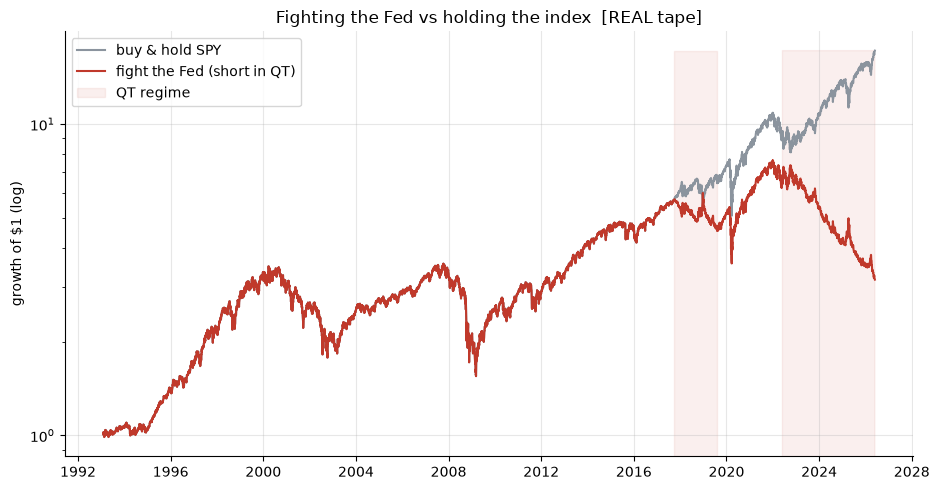

In [5]:
book = st.regime_timing_returns(bars, short_qt=True, cost_bps=5.0)
eq_bh = (1 + book['ret']).cumprod()
eq_rule = (1 + book['timing_net']).cumprod()
fig, ax = plt.subplots()
ax.plot(eq_bh.index, eq_bh, color=GREY, label='buy & hold SPY')
ax.plot(eq_rule.index, eq_rule, color=RED, label='fight the Fed (short in QT)')
# shade QT windows
qt = bars['regime'] == 'QT'
ax.fill_between(bars.index, 0, eq_bh.max(), where=qt.reindex(bars.index).fillna(False),
                color=RED, alpha=.08, label='QT regime')
ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)')
ax.set_title(f'Fighting the Fed vs holding the index  [{TAPE} tape]'); ax.legend()
plt.tight_layout(); plt.show()


## 5 · The verdict

| Axis | Stamp | Decisive statistics |
|---|---|---|
| Signal | **NONE** | QE − QT +2.54 bps, CI [-4.1, +9.15], *p* = 0.47; QT mean *t* = +2.35 (up, not down). |
| Tradability | **MIRAGE** | Net ann.: cash 8.05%, short 5.33% vs B&H 10.83%; ΔSharpe -0.27. |
| "Don't fight the Fed"? | **BUSTED** | Only QE − FLAT is significant — reverse causation, not a tradable signal. |

**REAL on the Signal axis was never on the table:** the contrast the claim depends on fails the inference bar outright (CI straddles zero). Literature on QE→*yields* is strong; QE→*equity-regime-drift* is not, and this tape can't certify it.

## 6 · Could you trade it?

There is no edge to cost out — break-even cost is undefined when the gross signal is already a loss against the benchmark. The honest 'capacity' statement is the opposite of usual: the rule has *plenty* of capacity (it trades a fraction of a time per year and is mostly in liquid SPY) and that capacity is worthless because the underlying contrast is noise. The real cost is **opportunity cost** — every day spent in cash or short during a rising QT market.

## 7 · Going further

- **Real `WALCL` once FRED is reachable.** Replace the announced-direction table with the weekly dollar level and its *rate of change* — test the continuous version, not just the sign.
- **Net liquidity.** The liquidity crowd quotes WALCL − Treasury General Account − reverse-repo balances, not gross assets; that series moves differently and deserves its own teardown.
- **Endogeneity head-on.** Instrument the balance sheet on pre-scheduled programme announcements to separate 'QE causes rallies' from 'the Fed eases into rallies'.

Below: the **synthetic positive control** — proof the harness *can* find a QE/QT edge when one is planted, so the NONE above is a real absence, not a dead pipeline.

In [6]:
# Machinery proof (synthetic only — NEVER cited in support of a real stamp).
rows = []
for edge, name in [(0.0, 'null'), (0.001, 'control (planted QE>QT)')]:
    f, _ = data.synthetic_daily(qe_edge=edge, seed=317)
    rmn = st.regime_means(f)
    ci = st.diff_block_bootstrap_ci(f, n_boot=2000, seed=1)
    rows.append({'tape': name, 'QE t': round(rmn.loc['QE','tstat'],2),
                 'QT t': round(rmn.loc['QT','tstat'],2),
                 'QE-QT bps': round(ci['diff_bps'],2),
                 'CI': f"[{ci['ci_lo']:+.1f}, {ci['ci_hi']:+.1f}]",
                 'finds signal?': 'no' if ci['ci_lo']<0<ci['ci_hi'] else 'YES'})
print('SYNTHETIC machinery proof — not market evidence')
pd.DataFrame(rows).set_index('tape')


SYNTHETIC machinery proof — not market evidence


,QE t,QT t,QE-QT bps,CI,finds signal?
tape,,,,,
null,-0.47,-0.95,3.28,"[-8.2, +14.3]",no
control (planted QE>QT),2.88,-2.98,23.27,"[+11.8, +34.3]",YES


> 💡 **In plain words.** Plant a real QE>QT drift and the harness flags it (CI excludes zero); plant nothing and it stays silent. So when the *real* tape comes back NONE, that is the market telling us there's no edge — not the test failing to look.